In [1]:
# we need to read the data but before theat we are going to import our libraries needed 
import numpy as np
import pandas as pd
import visuals as vs # Supplementary code
from sklearn.model_selection import ShuffleSplit

In [2]:
%matplotlib inline
data = pd.read_csv('housing.csv')
data.head()

,RM,LSTAT,PTRATIO,MEDV
0,6.575,4.98,15.3,504000.0
1,6.421,9.14,17.8,453600.0
2,7.185,4.03,17.8,728700.0
3,6.998,2.94,18.7,701400.0
4,7.147,5.33,18.7,760200.0


In [3]:
print(data.dtypes)

RM         float64
LSTAT      float64
PTRATIO    float64
MEDV       float64
dtype: object


In [4]:
data.shape

(489, 4)

In [5]:
data.describe()

,RM,LSTAT,PTRATIO,MEDV
count,489.000000,489.000000,489.000000,4.890000e+02
mean,6.240288,12.939632,18.516564,4.543429e+05
std,0.643650,7.081990,2.111268,1.653403e+05
min,3.561000,1.980000,12.600000,1.050000e+05
25%,5.880000,7.370000,17.400000,3.507000e+05
50%,6.185000,11.690000,19.100000,4.389000e+05
75%,6.575000,17.120000,20.200000,5.187000e+05
max,8.398000,37.970000,22.000000,1.024800e+06


In [6]:
data['MEDV'].describe()

count    4.890000e+02
mean     4.543429e+05
std      1.653403e+05
min      1.050000e+05
25%      3.507000e+05
50%      4.389000e+05
75%      5.187000e+05
max      1.024800e+06
Name: MEDV, dtype: float64

In [7]:
prices = data['MEDV']
features = data.drop('MEDV', axis = 1)

In [8]:
print('Boston housing dataset has {0} data points with {1} variables each.'.format(*data.shape))

Boston housing dataset has 489 data points with 4 variables each.


In [9]:
#calculating the statistics for the data
# TODO: Minimum price of the data
minimum_price = prices.min()

# TODO: Maximum price of the data
maximum_price = prices.max()
# TODO: Mean price of the data
mean_price =prices.mean() 

# TODO: Median price of the data
median_price = prices.median()

# TODO: Standard deviation of prices of the data
std_price = prices.std()

# Show the calculated statistics
print("Statistics for Boston housing dataset:\n")
print("Minimum price: ${:,.2f}".format(minimum_price))
print("Maximum price: ${:,.2f}".format(maximum_price))
print("Mean price: ${:,.2f}".format(mean_price))
print("Median price ${:,.2f}".format(median_price))
print("Standard deviation of prices: ${:,.2f}".format(std_price))

Statistics for Boston housing dataset:

Minimum price: $105,000.00
Maximum price: $1,024,800.00
Mean price: $454,342.94
Median price $438,900.00
Standard deviation of prices: $165,340.28


In [10]:
data.isnull().sum()

RM         0
LSTAT      0
PTRATIO    0
MEDV       0
dtype: int64

In [11]:
prices.isnull().sum()

np.int64(0)

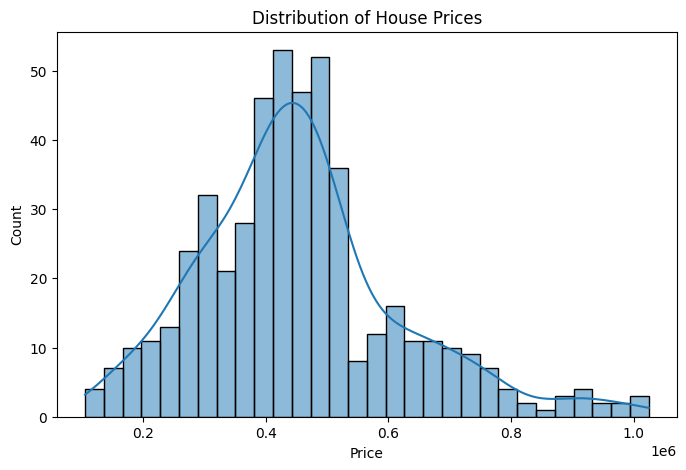

In [ ]:
# visualizing the MEDV  to see the disgtribution of the prices
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(data['MEDV'], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

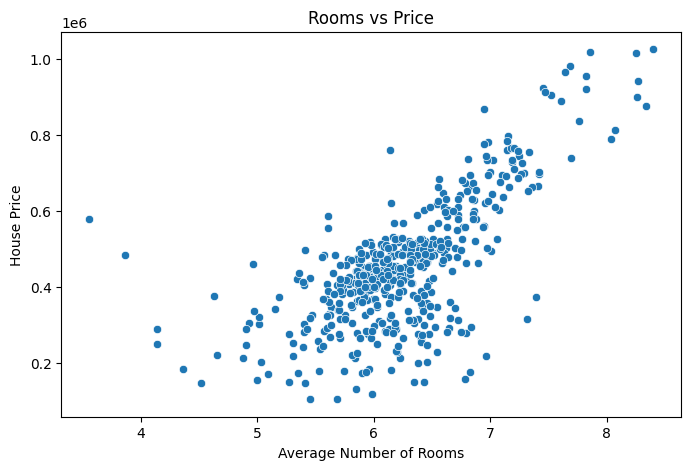

In [ ]:
# To visualize the relationship between the no.rooms and the price 
plt.figure(figsize=(8,5))
sns.scatterplot(x=data['RM'], y=data['MEDV'])

plt.title("Rooms vs Price")
plt.xlabel("Average Number of Rooms")
plt.ylabel("House Price")

plt.show()

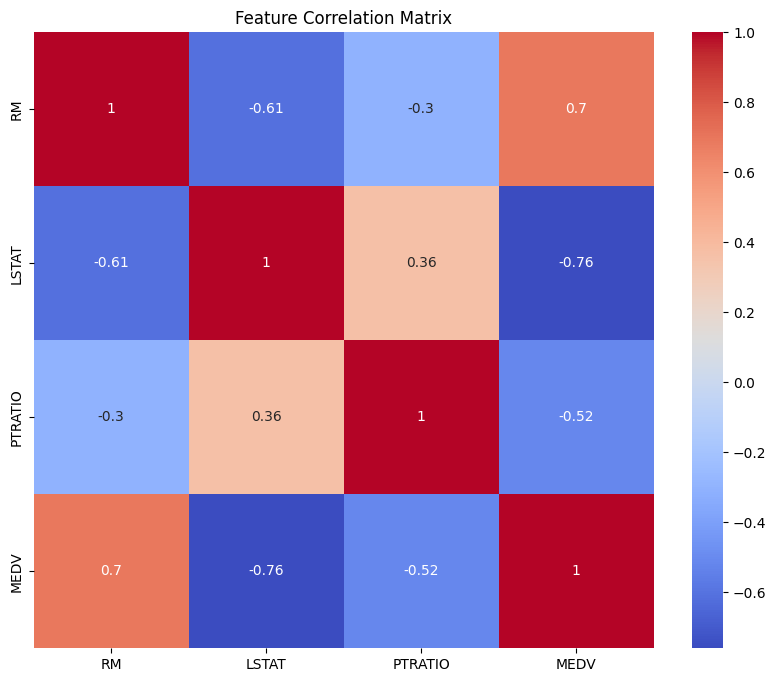

In [16]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")

plt.title("Feature Correlation Matrix")

plt.show()

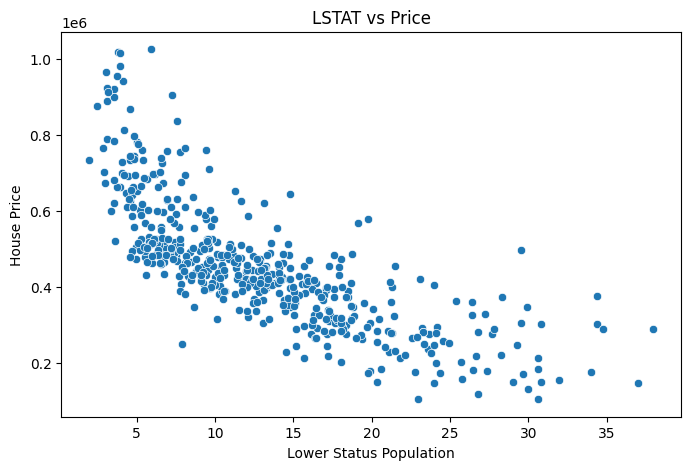

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=data['LSTAT'], y=data['MEDV'])

plt.title("LSTAT vs Price")
plt.xlabel("Lower Status Population")
plt.ylabel("House Price")

plt.show()

In [12]:
''' According to the features : 1)RM is the number of rooms in the house. So as the RM increases, the MEDV increases also 
 2) LSTAT is the poor class. So as the number of mower class increases , the MEDV decreases
 3)PTRATIO is the number of students to the teacher.So as the number of students increases ,the education becomes poor quality so the MEDV decreases ''' 

' According to the features : 1)RM is the number of rooms in the house. So as the RM increases, the MEDV increases also \n 2) LSTAT is the poor class. So as the number of mower class increases , the MEDV decreases\n 3)PTRATIO is the number of students to the teacher.So as the number of students increases ,the education becomes poor quality so the MEDV decreases '

In [13]:
# creating the function that is responsible for the R^2 metric
# TODO: Import 'r2_score'
from sklearn.metrics import r2_score

def performance_metric(y_test, y_predict):
    """ Calculates and returns the performance score between 
        test and predicted values based on the metric chosen. """
    
    # TODO: Calculate the performance score between 'y_test' and 'y_predict'
    score = r2_score(y_test, y_predict)
    
    # Return the score
    return score

In [14]:
# Calculate the performance of this model
score = performance_metric([3, -0.5, 2, 7, 4.2], [2.5, 0.0, 2.1, 7.8, 5.3])
print ("Model has a coefficient of determination, R^2, of {:.3f}.".format(score))

Model has a coefficient of determination, R^2, of 0.923.


In [15]:
# R^2, of 0.923. since the value of R^2 is 90% , then the model predictions is good 

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features, prices, 
    test_size=0.2, 
    random_state=42
)

print("Number of training samples:", len(X_train))
print("Number of testing samples:", len(X_test)) 
print("Training and testing split was successful.")

Number of training samples: 391
Number of testing samples: 98
Training and testing split was successful.


In [17]:
'''Splitting the dataset into training and testing sets allows us to evaluate how well the learning algorithm generalizes to unseen data. 
The model is trained on the training set and then evaluated on the testing set to check its predictive performance.
This helps detect problems such as overfitting, where the model performs well on training data but poorly on new data,
or underfitting, where the model fails to capture the underlying pattern in the data.'''

'Splitting the dataset into training and testing sets allows us to evaluate how well the learning algorithm generalizes to unseen data. \nThe model is trained on the training set and then evaluated on the testing set to check its predictive performance.\nThis helps detect problems such as overfitting, where the model performs well on training data but poorly on new data,\nor underfitting, where the model fails to capture the underlying pattern in the data.'

In [18]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve, ShuffleSplit, train_test_split
from sklearn.tree import DecisionTreeRegressor

# Suppress matplotlib user warnings
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

# Display inline matplotlib plots with IPython
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')

def ModelLearning(X, y):
    """Calculates the performance of several models with varying sizes of training data.
       The learning and testing scores for each model are then plotted."""
    
    # Create 10 cross-validation sets for training and testing
    cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=0)

    # Generate the training set sizes increasing by 50
    train_sizes = np.rint(np.linspace(1, X.shape[0] * 0.8 - 1, 9)).astype(int)

    # Create the figure window
    fig, axes = plt.subplots(2, 2, figsize=(10, 7))

    # Create four different models based on max_depth
    for k, depth in enumerate([1, 3, 6, 10]):
        # Create a Decision tree regressor at max_depth = depth
        regressor = DecisionTreeRegressor(max_depth=depth)

        # Calculate the training and testing scores
        sizes, train_scores, test_scores = learning_curve(
            regressor, X, y, cv=cv, train_sizes=train_sizes, scoring='r2'
        )
        
        # Find the mean and standard deviation for smoothing
        train_mean = np.mean(train_scores, axis=1)
        train_std = np.std(train_scores, axis=1)
        test_mean = np.mean(test_scores, axis=1)
        test_std = np.std(test_scores, axis=1)

        # Subplot the learning curve 
        ax = axes[k//2, k%2]
        ax.plot(sizes, train_mean, 'o-', color='r', label='Training Score')
        ax.plot(sizes, test_mean, 'o-', color='g', label='Testing Score')
        ax.fill_between(sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='r')
        ax.fill_between(sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='g')
        
        # Labels
        ax.set_title(f'max_depth = {depth}')
        ax.set_xlabel('Number of Training Points')
        ax.set_ylabel('Score')
        ax.set_xlim([0, X.shape[0] * 0.8])
        ax.set_ylim([-0.05, 1.05])
        ax.legend(loc='lower right')
    
    # Visual aesthetics
    fig.suptitle('Decision Tree Regressor Learning Performances', fontsize=16, y=1.03)
    fig.tight_layout()
    plt.show()

c:\Users\El-Wattaneya\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\El-Wattaneya\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\El-Wattaneya\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\El-Wattaneya\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\El-Wattaneya\Ap

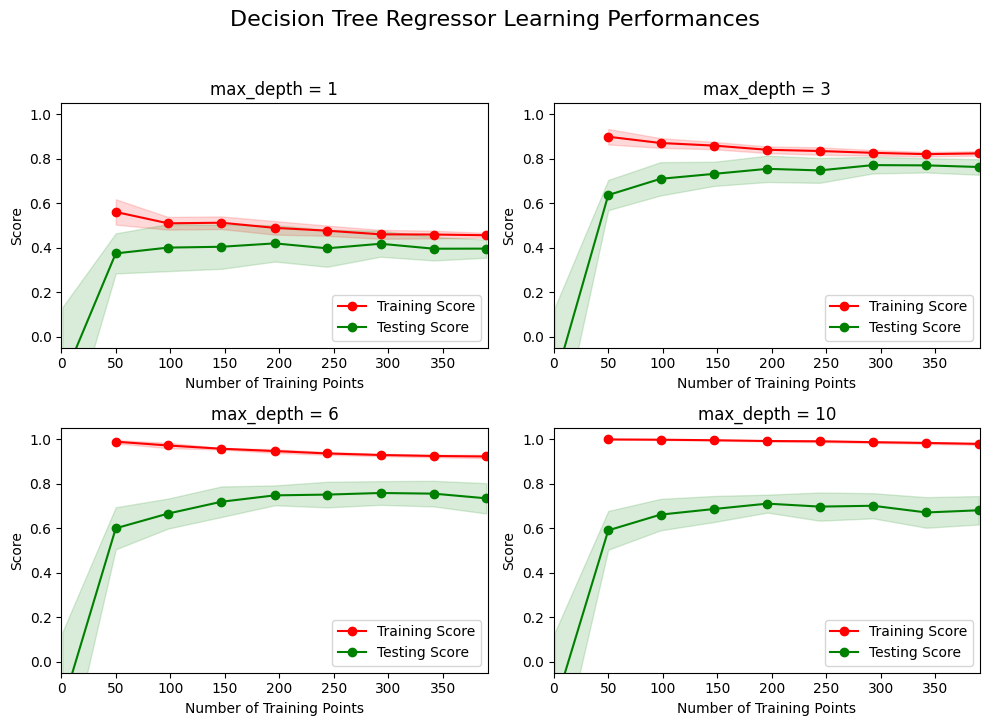

In [19]:
ModelLearning(features, prices)

In [ ]:
'''1.choosing The graph chosen to a Decision Tree Regressor with max_depth = 3.
As the number of training points increases, the training score gradually decreases slightly.
 This happens because when more training data is added, the model cannot perfectly fit all the training examples 
and therefore the training performance drops a little.
2. the testing score increases and then stabilizes as more training data is added.
 This indicates that the model is learning the general pattern of the data and improving its ability to generalize to unseen data.
3.both the training and testing curves start to converge to similar scores,
 which suggests that the model has learned most of the patterns available in the dataset.'''

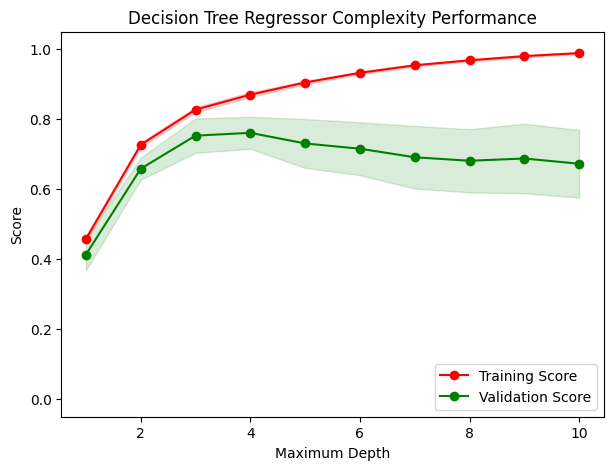

In [20]:
vs.ModelComplexity(X_train, y_train)

In [ ]:
'''Question 5 answer: 1. when the depth is equal to 1 , the model isn't complicated enough  to learn well from the training data ,This is called 
High Bias which indicates there is an underfitting 
2.when the depth is equal to 10 , the model is complicated and it learns well from the training data . This is called High Variance which is called 
in another term "overfitting"
'''

In [ ]:
''' Question 6 answer:The maximum depth that best generalizes to unseen data is max_depth = 4.

This is because the validation score reaches its highest point around this depth before starting to decline as the depth increases.
Increasing the depth further causes the model to overfit the training data, which results in lower validation performance.'''

In [ ]:
'''Question 7 answer: K-fold cross-validation is a technique used to evaluate the performance of a machine learning model by splitting the dataset into k equal parts (folds).
The model is trained k times, where each time one fold is used as the testing set and the remaining folds are used for training.
The final performance of the model is calculated as the average of the k .
This technique provides a major benefit when used with grid search for model optimization.
Instead of evaluating each parameter combination using only one training and testing split, k-fold cross-validation evaluates the model across
multiple splits of the data. This helps reduce bias that may occur from using a single subset of data and provides a more reliable estimate of model performance, leading to better parameter selection.'''

In [21]:
# TODO: Import 'make_scorer', 'DecisionTreeRegressor', and 'GridSearchCV'
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV

def fit_model(X, y):
    """ Performs grid search over the 'max_depth' parameter for a 
        decision tree regressor trained on the input data [X, y]. """
    
    # Create cross-validation sets from the training data
    cv_sets = ShuffleSplit(n_splits=10, test_size=0.20, random_state=0)

    # TODO: Create a decision tree regressor object
    regressor = DecisionTreeRegressor()

    # TODO: Create a dictionary for the parameter 'max_depth' with a range from 1 to 10
    params = {'max_depth': list(range(1,11))}

    # TODO: Transform 'performance_metric' into a scoring function using 'make_scorer' 
    scoring_fnc = make_scorer(performance_metric)

    # TODO: Create the grid search object
    grid = GridSearchCV(regressor, params, scoring = scoring_fnc, cv = cv_sets)

    # Fit the grid search object to the data to compute the optimal model
    grid = grid.fit(X, y)

    # Return the optimal model after fitting the data
    return grid.best_estimator_

In [ ]:
'''Question 9 answer:the optimal answer is the depth equals to 3 as presented in the gragh '''

In [23]:
# Fit the training data to the model using grid search
reg = fit_model(X_train, y_train)

# Produce the value for 'max_depth'
print ("Parameter 'max_depth' is {} for the optimal model.".format(reg.get_params()['max_depth']))

Parameter 'max_depth' is 4 for the optimal model.


In [ ]:
# Produce a matrix for client data
client_data = [[5, 34, 15], # Client 1
               [4, 55, 22], # Client 2
               [8, 7, 12]]  # Client 3

# Show predictions
for i, price in enumerate(reg.predict(client_data)):
    print("Predicted selling price for Client {}'s home: ${:,.2f}".format(i+1, price))
'''These prices appear reasonable given the values of the features. Client 3 has the largest house with 8 rooms, the lowest neighborhood poverty level (3%), and the best student-teacher ratio,
 which explains the highest predicted price. On the other hand, Client 2 has the smallest house, the highest poverty level (32%), and a higher student-teacher ratio, 
 resulting in the lowest predicted price. Client 1 falls between the two in terms of features, so the predicted price is also in the middle.'''

Predicted selling price for Client 1's home: $344,400.00
Predicted selling price for Client 2's home: $237,478.72
Predicted selling price for Client 3's home: $931,636.36


c:\Users\El-Wattaneya\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [25]:
import pickle


with open("house_price_model.pkl", "wb") as file:
    pickle.dump(reg, file)